# Import Data

In [1]:
from pm4py.objects.log.importer.xes import importer as xes_importer

path = r"C:\Users\admin\Downloads\data\Sepsis Cases - Event Log.xes"

log = xes_importer.apply(path)

print(log)

c:\Users\admin\anaconda3\envs\pm\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
c:\Users\admin\anaconda3\envs\pm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 1050/1050 [00:00<00:00, 2020.55it/s]

[{'attributes': {'concept:name': 'A'}, 'events': [{'InfectionSuspected': True, 'org:group': 'A', 'DiagnosticBlood': True, 'DisfuncOrg': True, 'SIRSCritTachypnea': True, 'Hypotensie': True, 'SIRSCritHeartRate': True, 'Infusion': True, 'DiagnosticArtAstrup': True, 'concept:name': 'ER Registration', 'Age': 85, 'DiagnosticIC': True, 'DiagnosticSputum': False, 'DiagnosticLiquor': False, 'DiagnosticOther': False, 'SIRSCriteria2OrMore': True, 'DiagnosticXthorax': True, 'SIRSCritTemperature': True, 'time:timestamp': datetime.datetime(2014, 10, 22, 11, 15, 41, tzinfo=datetime.timezone.utc), 'DiagnosticUrinaryCulture': True, 'SIRSCritLeucos': False, 'Oligurie': False, 'DiagnosticLacticAcid': True, 'lifecycle:transition': 'complete', 'Diagnose': 'A', 'Hypoxie': False, 'DiagnosticUrinarySediment': True, 'DiagnosticECG': True}, '..', {'org:group': 'E', 'lifecycle:transition': 'complete', 'concept:name': 'Release A', 'time:timestamp': datetime.datetime(2014, 11, 2, 15, 15, tzinfo=datetime.timezone.u

# Data Explorary

In [2]:
from pm4py.statistics.traces.generic.log import case_statistics

variants = case_statistics.get_variant_statistics(log)
print("Number of variants:", len(variants))
print("Number of traces:", len(log))
print("Number of events:", sum(len(trace) for trace in log))
print("Avg trace length:", sum(len(trace) for trace in log)/len(log))

Number of variants: 846
Number of traces: 1050
Number of events: 15214
Avg trace length: 14.48952380952381


In [3]:
attributes = set()

for trace in log:
    for event in trace:
        attributes.update(event.keys())

print("Event-level attributes:", attributes)

Event-level attributes: {'DisfuncOrg', 'DiagnosticBlood', 'DiagnosticUrinarySediment', 'DiagnosticOther', 'DiagnosticSputum', 'SIRSCriteria2OrMore', 'DiagnosticLiquor', 'SIRSCritTemperature', 'time:timestamp', 'Leucocytes', 'Infusion', 'CRP', 'DiagnosticECG', 'Hypotensie', 'Oligurie', 'InfectionSuspected', 'Age', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Diagnose', 'LacticAcid', 'Hypoxie', 'SIRSCritHeartRate', 'DiagnosticIC', 'DiagnosticXthorax', 'org:group', 'concept:name', 'DiagnosticLacticAcid', 'DiagnosticArtAstrup', 'lifecycle:transition', 'SIRSCritTachypnea'}


In [4]:
from pm4py.statistics.attributes.log import get as attributes_get

activities_count = attributes_get.get_attribute_values(log, "concept:name")
print("Activities frequency:", activities_count)

Activities frequency: {'ER Registration': 1050, 'Leucocytes': 3383, 'CRP': 3262, 'LacticAcid': 1466, 'ER Triage': 1053, 'ER Sepsis Triage': 1049, 'IV Liquid': 753, 'IV Antibiotics': 823, 'Admission NC': 1182, 'Release A': 671, 'Return ER': 294, 'Admission IC': 117, 'Release B': 56, 'Release C': 25, 'Release D': 24, 'Release E': 6}


In [5]:
from pm4py.statistics.start_activities.log import get as start_activities_get
from pm4py.statistics.end_activities.log import get as end_activities_get

start_activities = start_activities_get.get_start_activities(log)
end_activities = end_activities_get.get_end_activities(log)\

print("Start activities:", start_activities)
print("End activities:", end_activities)

Start activities: {'ER Registration': 995, 'IV Liquid': 14, 'ER Triage': 6, 'CRP': 10, 'ER Sepsis Triage': 7, 'Leucocytes': 18}
End activities: {'Release A': 393, 'Return ER': 291, 'IV Antibiotics': 87, 'Release B': 55, 'ER Sepsis Triage': 49, 'Leucocytes': 44, 'IV Liquid': 12, 'Release C': 19, 'CRP': 41, 'LacticAcid': 24, 'Release D': 14, 'Admission NC': 14, 'Release E': 5, 'ER Triage': 2}


In [6]:
from pm4py.statistics.attributes.log import get as attributes_get

org_group = attributes_get.get_attribute_values(log, "org:group")
print("org:group distribution:", org_group)

org:group distribution: {'A': 3462, 'B': 8111, 'C': 1053, 'D': 47, 'E': 782, 'F': 216, 'G': 148, 'H': 55, '?': 294, 'I': 126, 'J': 26, 'K': 18, 'L': 213, 'M': 84, 'N': 46, 'O': 186, 'P': 59, 'Q': 63, 'R': 57, 'S': 33, 'T': 35, 'U': 18, 'V': 25, 'W': 55, 'X': 1, 'Y': 1}


In [7]:
from pm4py.objects.conversion.log import converter as log_converter

df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

print(df.head())
print("\nColumns:", df.columns)

  InfectionSuspected org:group DiagnosticBlood DisfuncOrg SIRSCritTachypnea  \
0               True         A            True       True              True   
1                NaN         B             NaN        NaN               NaN   
2                NaN         B             NaN        NaN               NaN   
3                NaN         B             NaN        NaN               NaN   
4                NaN         C             NaN        NaN               NaN   

  Hypotensie SIRSCritHeartRate Infusion DiagnosticArtAstrup     concept:name  \
0       True              True     True                True  ER Registration   
1        NaN               NaN      NaN                 NaN       Leucocytes   
2        NaN               NaN      NaN                 NaN              CRP   
3        NaN               NaN      NaN                 NaN       LacticAcid   
4        NaN               NaN      NaN                 NaN        ER Triage   

   ...  DiagnosticLacticAcid lifecycle:trans

In [8]:
from collections import Counter
import pandas as pd
import numpy as np
import math

def build_traces(df):
    traces = []
    for _, g in df.groupby("case:concept:name"):
        g = g.sort_values("time:timestamp")
        traces.append(g["concept:name"].tolist())
    return traces

def trace_entropy(traces):
    variants = ["->".join(t) for t in traces]

    counts = Counter(variants)
    total = len(variants)

    entropy = 0.0
    for c in counts.values():
        p = c / total
        entropy -= p * math.log(p)

    return entropy


traces = build_traces(df)

entropy_value = trace_entropy(traces)

print(entropy_value)

6.469860848166022


In [9]:
def activity_optionality(df):
    total_cases = df["case:concept:name"].nunique()

    coverage = (
        df.groupby("concept:name")["case:concept:name"]
        .nunique()
        .sort_values(ascending=False)
    )

    coverage = coverage / total_cases

    return coverage


coverage = activity_optionality(df)

print(coverage)

concept:name
ER Registration     1.000000
ER Triage           1.000000
ER Sepsis Triage    0.999048
Leucocytes          0.963810
CRP                 0.959048
LacticAcid          0.819048
IV Antibiotics      0.783810
Admission NC        0.761905
IV Liquid           0.717143
Release A           0.639048
Return ER           0.280000
Admission IC        0.104762
Release B           0.053333
Release C           0.023810
Release D           0.022857
Release E           0.005714
Name: case:concept:name, dtype: float64


In [10]:
def inter_event_variability(df):

    df = df.copy()
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

    inter_times = []

    for _, g in df.groupby("case:concept:name"):
        g = g.sort_values("time:timestamp")

        t = g["time:timestamp"].values
        if len(t) < 2:
            continue

        diffs = np.diff(t) / np.timedelta64(1, "h")
        inter_times.extend(diffs)

    inter_times = np.array(inter_times)

    result = {
        "mean": np.mean(inter_times),
        "std": np.std(inter_times),
        "min": np.min(inter_times),
        "max": np.max(inter_times),
        "iqr": np.percentile(inter_times, 75) - np.percentile(inter_times, 25)
    }

    return result


time_stats = inter_event_variability(df)

for k, v in time_stats.items():
    print(k, ":", v)

mean : 50.65146845288525
std : 415.18024419742017
min : 0.0
max : 10014.255
iqr : 7.25


# Data Preprocessing

In [11]:
from pm4py.objects.conversion.log import converter as log_converter
import pandas as pd

df = df.copy()

df = df.dropna(subset=["case:concept:name", "concept:name", "time:timestamp"])

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")
df = df.dropna(subset=["time:timestamp"])

df = df.sort_values(["case:concept:name", "time:timestamp"])

case_sizes = df.groupby("case:concept:name").size()
valid_cases = case_sizes[(case_sizes >= 3) & (case_sizes <= 150)].index
df = df[df["case:concept:name"].isin(valid_cases)]

parameters = {
    log_converter.Variants.TO_EVENT_LOG.value.Parameters.CASE_ID_KEY: "case:concept:name"
}

event_log = log_converter.apply(df, parameters=parameters)

In [12]:
print("Number of cases:", len(event_log))

print("\nExample trace:")
print([x["concept:name"] for x in event_log[0]])

print("\nNumber of traces (variants):", len(event_log))

print("\nFirst 5 traces:")
for i in range(min(5, len(event_log))):
    print([x["concept:name"] for x in event_log[i]])

Number of cases: 1048

Example trace:
['ER Registration', 'Leucocytes', 'CRP', 'LacticAcid', 'ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'IV Antibiotics', 'Admission NC', 'CRP', 'Leucocytes', 'Leucocytes', 'CRP', 'Leucocytes', 'CRP', 'CRP', 'Leucocytes', 'Leucocytes', 'CRP', 'CRP', 'Leucocytes', 'Release A']

Number of traces (variants): 1048

First 5 traces:
['ER Registration', 'Leucocytes', 'CRP', 'LacticAcid', 'ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'IV Antibiotics', 'Admission NC', 'CRP', 'Leucocytes', 'Leucocytes', 'CRP', 'Leucocytes', 'CRP', 'CRP', 'Leucocytes', 'Leucocytes', 'CRP', 'CRP', 'Leucocytes', 'Release A']
['ER Registration', 'ER Triage', 'ER Sepsis Triage', 'Leucocytes', 'LacticAcid', 'CRP', 'IV Liquid', 'IV Antibiotics']
['ER Registration', 'ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'Leucocytes', 'CRP', 'LacticAcid', 'IV Antibiotics', 'Admission NC', 'Release A', 'Return ER']
['ER Registration', 'ER Triage', 'ER Sepsis Triage', 'CRP', 'LacticAcid', 'Leucocy

# Process Discovery

## Heuristics Miner

In [13]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Users\admin\Downloads\Graphviz\bin"

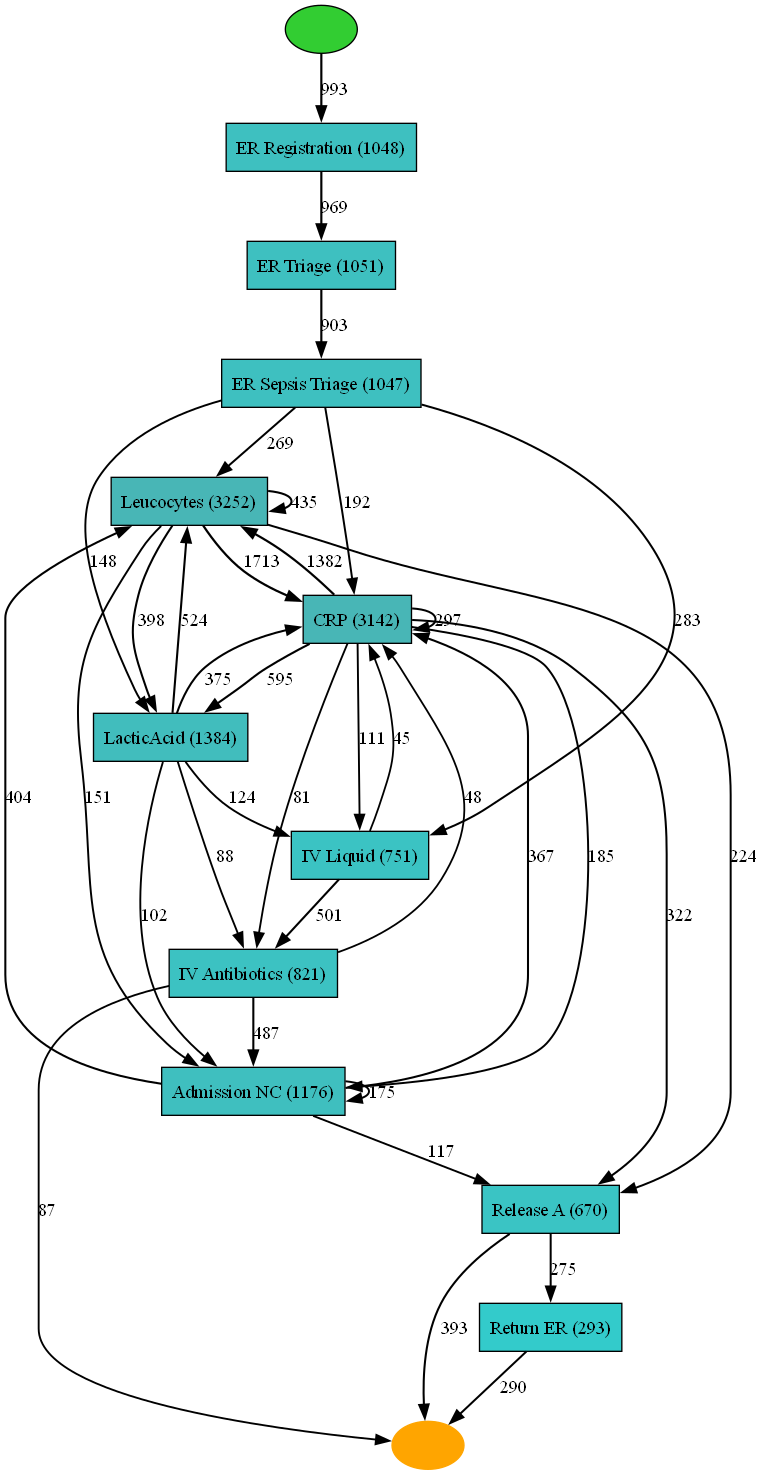

In [14]:
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer

heu_net = heuristics_miner.apply_heu(
    event_log,
    parameters={
        "dependency_threshold": 0.98,
        "min_act_count": 100,
        "min_dfg_occurrences": 80
    }
)

gviz = hn_visualizer.apply(heu_net)
hn_visualizer.view(gviz)

In [15]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.objects.conversion.heuristics_net import converter as hn_converter

net, im, fm = hn_converter.apply(heu_net)

replayed_traces = token_replay.apply(
    event_log,
    net,
    im,
    fm
)

fitness_values = [t["trace_fitness"] for t in replayed_traces]

print("Average Token-based fitness:", sum(fitness_values) / len(fitness_values))
print(replayed_traces[0])

replaying log with TBR, completed traces :: 100%|██████████| 844/844 [00:01<00:00, 520.31it/s]

Average Token-based fitness: 0.9280811877776598
{'trace_is_fit': False, 'trace_fitness': 0.9426532769556026, 'activated_transitions': [(ER Registration, 'ER Registration'), (Leucocytes, 'Leucocytes'), (hid_35, None), (CRP, 'CRP'), (hid_46, None), (LacticAcid, 'LacticAcid'), (ER Triage, 'ER Triage'), (hid_66, None), (ER Sepsis Triage, 'ER Sepsis Triage'), (hid_69, None), (IV Liquid, 'IV Liquid'), (hid_64, None), (IV Antibiotics, 'IV Antibiotics'), (hid_56, None), (Admission NC, 'Admission NC'), (hid_51, None), (CRP, 'CRP'), (hid_47, None), (Leucocytes, 'Leucocytes'), (hid_37, None), (Leucocytes, 'Leucocytes'), (hid_61, None), (CRP, 'CRP'), (hid_47, None), (Leucocytes, 'Leucocytes'), (hid_35, None), (CRP, 'CRP'), (hid_43, None), (CRP, 'CRP'), (hid_47, None), (Leucocytes, 'Leucocytes'), (hid_37, None), (Leucocytes, 'Leucocytes'), (hid_35, None), (CRP, 'CRP'), (hid_43, None), (CRP, 'CRP'), (hid_47, None), (Leucocytes, 'Leucocytes'), (Release A, 'Release A'), (hid_39, None)], 'reached_marki

In [16]:
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

aligned_traces = alignments.apply_log(
    event_log,
    net,
    im,
    fm
)

fitness_values = [t["fitness"] for t in aligned_traces]

print("Average Alignment fitness:", sum(fitness_values) / len(fitness_values))
print("Example alignment:")
print(aligned_traces[0])

aligning log, completed variants :: 100%|██████████| 844/844 [03:56<00:00,  3.56it/s]

Average Alignment fitness: 0.8642004235678878
Example alignment:
{'alignment': [('ER Registration', 'ER Registration'), ('>>', 'ER Triage'), ('>>', None), ('>>', 'ER Sepsis Triage'), ('>>', None), ('Leucocytes', 'Leucocytes'), ('>>', None), ('CRP', 'CRP'), ('>>', None), ('LacticAcid', 'LacticAcid'), ('ER Triage', '>>'), ('ER Sepsis Triage', '>>'), ('>>', None), ('IV Liquid', 'IV Liquid'), ('>>', None), ('IV Antibiotics', 'IV Antibiotics'), ('>>', None), ('Admission NC', 'Admission NC'), ('CRP', 'CRP'), ('>>', None), ('Leucocytes', 'Leucocytes'), ('>>', None), ('Leucocytes', 'Leucocytes'), ('>>', None), ('CRP', 'CRP'), ('>>', None), ('Leucocytes', 'Leucocytes'), ('>>', None), ('CRP', 'CRP'), ('>>', None), ('CRP', 'CRP'), ('>>', None), ('Leucocytes', 'Leucocytes'), ('>>', None), ('Leucocytes', 'Leucocytes'), ('>>', None), ('CRP', 'CRP'), ('>>', None), ('CRP', 'CRP'), ('Leucocytes', 'Leucocytes'), ('Release A', 'Release A'), ('>>', None)], 'cost': 40018, 'visited_states': 227, 'queued_sta

## Inductive Miner

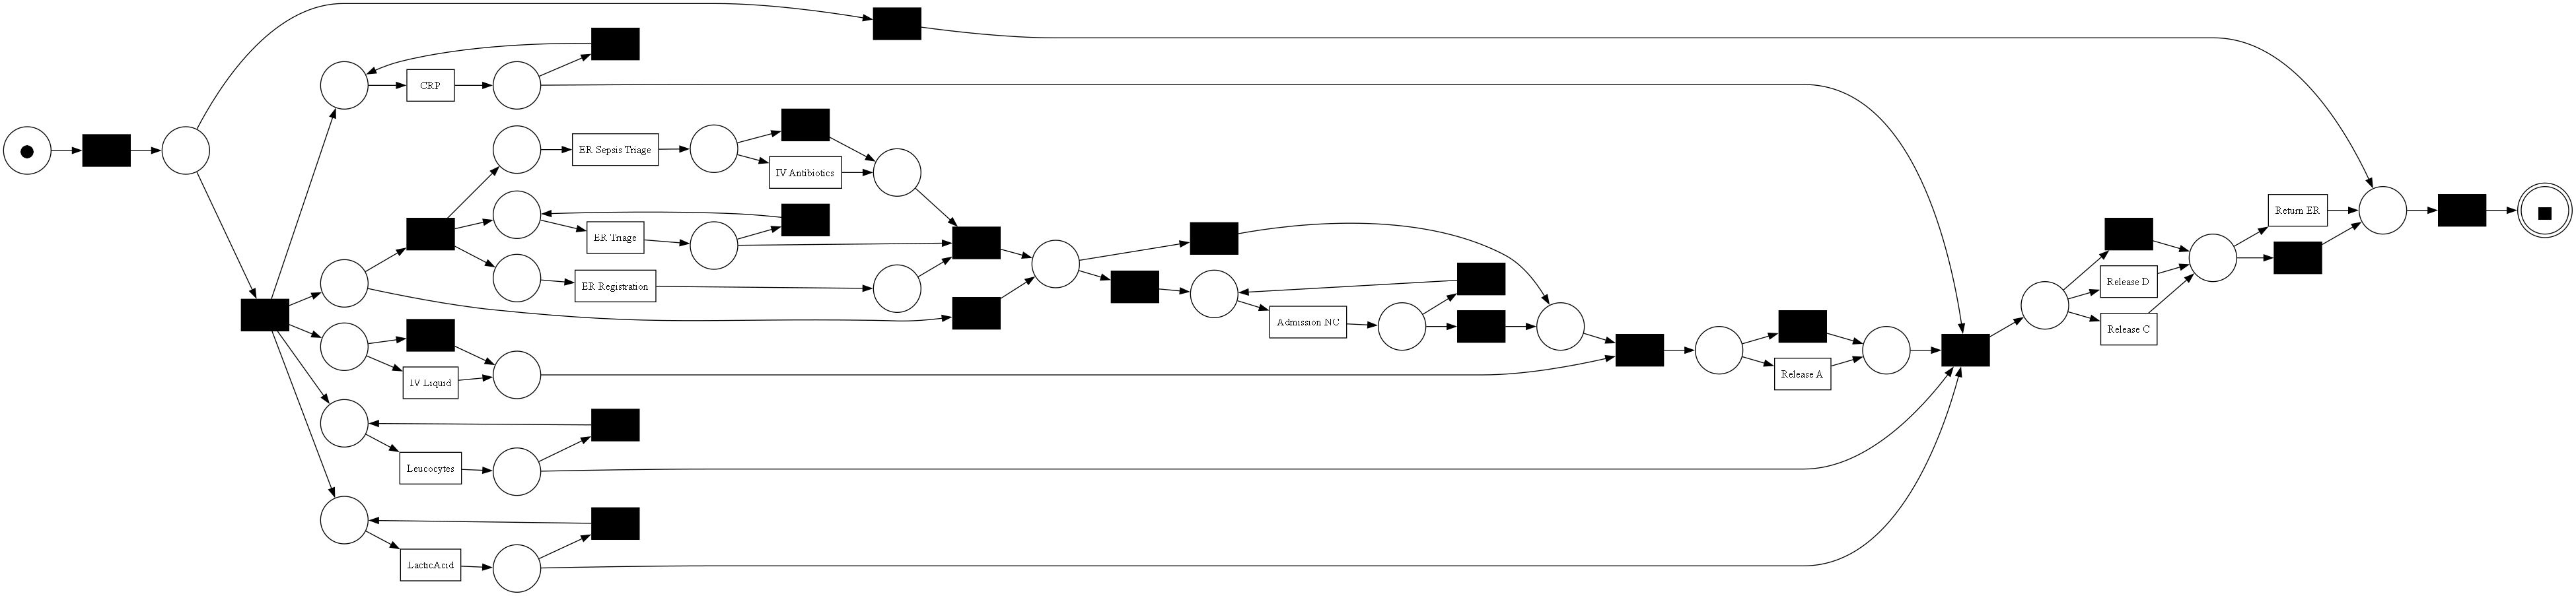

In [17]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer

tree = inductive_miner.apply(
    event_log,
    variant=inductive_miner.Variants.IMf,
    parameters={
        "noise_threshold": 0.2
    }
)

net, im, fm = pt_converter.apply(tree, variant=pt_converter.Variants.TO_PETRI_NET)

gviz = pn_visualizer.apply(net, im, fm)

pn_visualizer.view(gviz)

In [18]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

replayed = token_replay.apply(event_log, net, im, fm)

fitness = [t["trace_fitness"] for t in replayed]

print("Token-based fitness:", sum(fitness)/len(fitness))

replaying log with TBR, completed traces :: 100%|██████████| 844/844 [00:01<00:00, 816.93it/s]


Token-based fitness: 0.9796056917352335


In [19]:
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

aligned = alignments.apply_log(event_log, net, im, fm)

fitness = [t["fitness"] for t in aligned]

print("Alignment fitness:", sum(fitness)/len(fitness))

aligning log, completed variants :: 100%|██████████| 844/844 [00:14<00:00, 59.95it/s] 

Alignment fitness: 0.9339227471030179
